# Lasso Regression

This notebook trains a Lasso (L1 regularized) regression model to predict car prices. Using cross-validated tuning over the alpha penalty, it drives negligible feature coefficients to zero, achieving automatic feature selection.

## 1. Imports

In [12]:
# suppress warnings to keep notebook clean
import warnings
warnings.filterwarnings("ignore")

# data processing and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn lasso, preprocessing, and evaluation metrics
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

# random seed and visual theme
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Dataset audit and preprocessing

In [ ]:
# dataset source and target variable
DATA_URL = "https://raw.githubusercontent.com/rohithtej2109/Smart-car-deals/b438f32fc37ae91e6f8a72ef912705b2c48b427f/cardekho_dataset.csv"
TARGET = "selling_price"

df = pd.read_csv(DATA_URL)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# convert target to numeric and drop duplicate rows
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df.drop_duplicates().dropna(subset=[TARGET]).copy()

# split features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# categorize feature types
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

# construct column transformer pipeline
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

# display dataset dimensions
print("Shape:", df.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Shape: (15411, 14)
Numeric features: ['unnamed:_0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Categorical features: ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


## 3. Required EDA

,unnamed:_0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
unnamed:_0,15411.0,NaN,NaN,NaN,9811.857699,5643.418542,0.0,4906.5,9872.0,14668.5,19543.0
car_name,15411,121,Hyundai i20,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,15411,32,Maruti,4992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,15411,120,i20,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_age,15411.0,NaN,NaN,NaN,6.036338,3.013291,0.0,4.0,6.0,8.0,29.0
km_driven,15411.0,NaN,NaN,NaN,55616.480631,51618.548422,100.0,30000.0,50000.0,70000.0,3800000.0
seller_type,15411,3,Dealer,9539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,15411,5,Petrol,7643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission_type,15411,2,Manual,12225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,15411.0,NaN,NaN,NaN,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54


Missing values:
 unnamed:_0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64


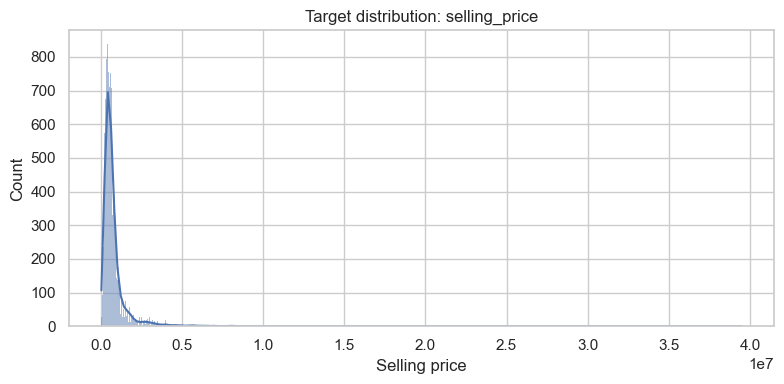

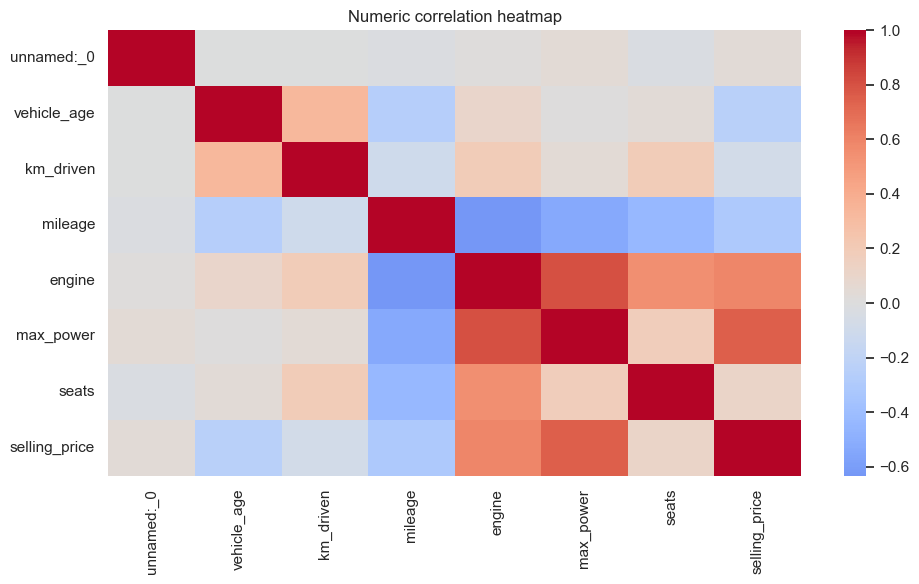

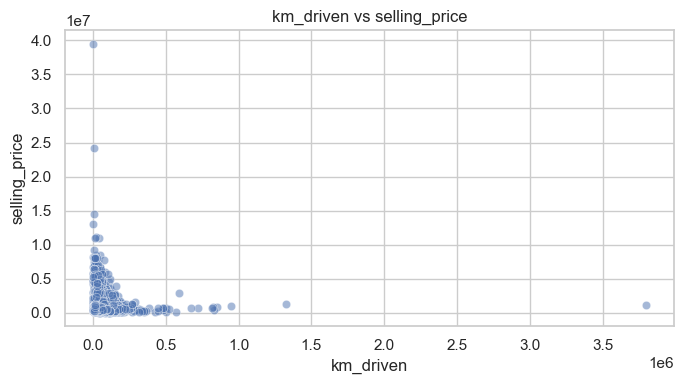

In [7]:
# inspect first rows, summary stats, and missing values
display(df.head())
display(df.describe(include="all").T)
print("Missing values:\n", df.isna().sum())

# target distribution plot
plt.figure(figsize=(8,4)); sns.histplot(y, kde=True); plt.title("Target distribution: selling_price"); plt.xlabel("Selling price"); plt.tight_layout(); plt.show()

# numeric correlation heatmap
plt.figure(figsize=(10,6)); sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", center=0); plt.title("Numeric correlation heatmap"); plt.tight_layout(); plt.show()

# scatter plots of key numerical features vs target
for col in [c for c in ["year","km_driven","car_age"] if c in df.columns]:
    plt.figure(figsize=(7,4)); sns.scatterplot(data=df, x=col, y=TARGET, alpha=.5); plt.title(f"{col} vs selling_price"); plt.tight_layout(); plt.show()

## 4. Model training and optional tuning

In [8]:
# build pipeline with lasso regressor
base_model = Lasso(max_iter=20000)
model = Pipeline([("preprocessor", preprocessor), ("model", base_model)])

In [9]:
# tune alpha via 5-fold grid search
param_grid = {'model__alpha':[0.0001,0.001,0.01,0.1,1,10]}
search = GridSearchCV(model, param_grid, cv=5, scoring="r2", n_jobs=-1)
search.fit(X_train, y_train)

# extract best model
model = search.best_estimator_
print("Best parameters:", search.best_params_)

Best parameters: {'model__alpha': 10}


## 5. Evaluation

In [14]:
# evaluate on test data
pred = model.predict(X_test)
results = pd.DataFrame([{
    "Model": 'Lasso Regression',
    "R2": r2_score(y_test, pred),
    "RMSE": root_mean_squared_error(y_test, pred),
    "MAE": mean_absolute_error(y_test, pred)
}])
display(results)

# 5-fold cross validation score
cv_r2 = cross_val_score(model, X, y, cv=5, scoring="r2", n_jobs=-1)
print("5-fold CV R2 mean:", cv_r2.mean())
print("5-fold CV R2 std:", cv_r2.std())

,Model,R2,RMSE,MAE
0,Lasso Regression,0.796651,391251.289533,178407.627099


5-fold CV R2 mean: 0.7091305240831652
5-fold CV R2 std: 0.11177423693473039


## 6. Required visualisations / interpretation

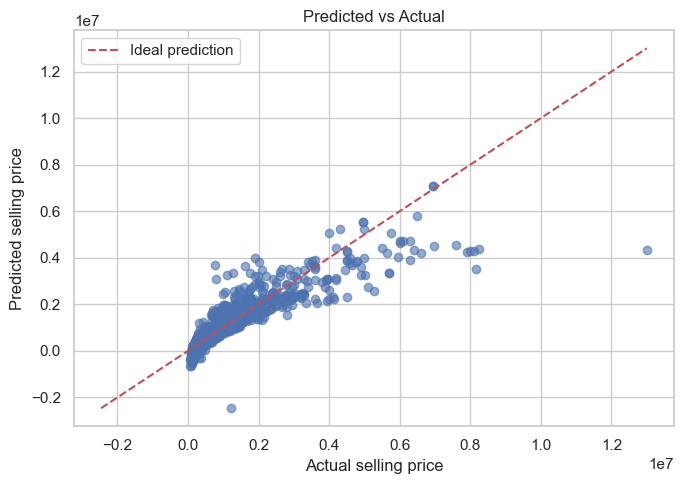

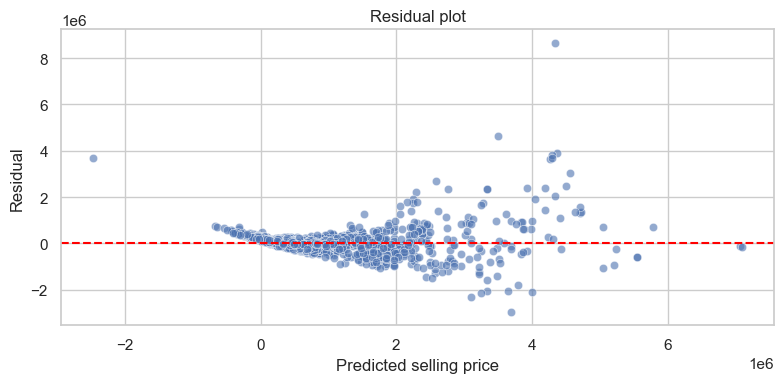

In [15]:
# plot predicted vs actual prices
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(y_test, pred, alpha=.6)
lims=[min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, "r--", label="Ideal prediction")
ax.set_xlabel("Actual selling price"); ax.set_ylabel("Predicted selling price")
ax.set_title("Predicted vs Actual"); ax.legend(); plt.tight_layout(); plt.show()

# plot residuals
residuals = y_test - pred
plt.figure(figsize=(8,4)); sns.scatterplot(x=pred, y=residuals, alpha=.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted selling price"); plt.ylabel("Residual")
plt.title("Residual plot"); plt.tight_layout(); plt.show()

# plot top feature importances if available
if hasattr(model.named_steps["model"], "feature_importances_"):
    names = model.named_steps["preprocessor"].get_feature_names_out()
    imp = pd.Series(model.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8,5)); imp.sort_values().plot(kind="barh")
    plt.title("Top feature importances"); plt.xlabel("Importance"); plt.tight_layout(); plt.show()

### Interpretation & Observations

- **Hyperparameter Selection:** Grid search selected **$\alpha = 10$**, indicating that a relatively strong L1 penalty is favored. This forces negligible dummy variables and weak predictors strictly to zero, producing a parsimonious model.
- **Accuracy & Parsimony:** Despite zeroing out weak coefficients, Lasso maintains strong predictive accuracy with a test $R^2$ of **0.7967 (~79.7%)**, an MAE of **₹178,408**, and an RMSE of **₹391,251**, matching unregularized OLS (0.7997).
- **Cross-Validation Dynamics:** The 5-fold CV mean score is **0.7091 ($\pm 0.1118$)**. The slight increase in CV standard deviation compared to Ridge reflects L1 penalty's aggressive zeroing of coefficients when certain sparse categorical levels appear unevenly across cross-validation splits.
- **Residual Distribution:** As with other linear estimators, the residual plot confirms good calibration for cars under ₹15-20 lakh, with higher variance and under-prediction for upper-tier luxury vehicles.